# DIS Stockholm Spring 2026 Machine Learning Project Proposal

## Predicting Citi Bike Trip Duration


## Project Overview

Our project is a regression problem. We want to predict the duration of a Citi Bike trip using information that is available in the trip history dataset.

**Problem statement:** Given a Citi Bike ride's time, start/end location information, bike type, and rider type, can we predict how long the ride lasted?

**Target variable:** `trip_duration_minutes`, derived from:

`ended_at - started_at`

This target is well defined because every valid trip record includes a start timestamp and an end timestamp. We will measure the target in minutes because that is easier to interpret than seconds.

**Why this matters:** Trip duration is useful because it connects to system usage, operational planning, and user behavior. For example, longer rides may affect bike availability, battery usage for e-bikes, and station balancing. We are not claiming we can solve operations planning from one month of data, but duration prediction is a practical starting point for learning from real transportation data.

**Possible extension:** We may also explore classification of `member_casual` later, but that is not the main project. The main task is duration regression.

## Dataset Description

We are using the official Citi Bike trip history data for May 2025. Citi Bike publishes trip history files for public analysis, including fields such as ride ID, bike type, start/end timestamps, station names and IDs, coordinates, and whether the rider was a member or casual rider.

We combined the May 2025 files into one CSV:

- Combined file: `202505-citibike-tripdata.csv`
- File size: about 805 MB
- Total lines: 4,325,554
- Trip rows: 4,325,553
- Header rows: 1

The variables are:

- `ride_id`
- `rideable_type`
- `started_at`
- `ended_at`
- `start_station_name`
- `start_station_id`
- `end_station_name`
- `end_station_id`
- `start_lat`, `start_lng`
- `end_lat`, `end_lng`
- `member_casual`


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
plt.rcParams['figure.figsize'] = (9, 5)

CSV_PATH = Path('202505-citibike-tripdata.csv')

CSV_PATH

PosixPath('202505-citibike-tripdata.csv')

In [ ]:
file_size_mb = CSV_PATH.stat().st_size / (1024 ** 2)
print(f'CSV path: {CSV_PATH}')
print(f'File size: {file_size_mb:,.1f} MB')

CSV path: 202505-citibike-tripdata.csv
File size: 805.3 MB


## Data Loading


In [ ]:
DATE_COLUMNS = ['started_at', 'ended_at']
RANDOM_STATE = 42

df_full = pd.read_csv(CSV_PATH, parse_dates=DATE_COLUMNS, low_memory=False)
df_clean = df_full.dropna().copy()

print(f'Full dataset shape: {df_full.shape}')
print(f'Clean dataset shape after dropna(): {df_clean.shape}')
print(f'Rows dropped because of missing values: {len(df_full) - len(df_clean):,}')
display(df_clean)

Full dataset shape: (4325553, 13)
Clean dataset shape after dropna(): (4311373, 13)
Rows dropped because of missing values: 14,180


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,9DD48ABED65F7015,classic_bike,2025-05-04 14:19:21.329,2025-05-04 14:24:15.721,W Broadway & Spring St,5569.06,Lafayette St & Grand St,5422.09,40.724947,-74.001659,40.720280,-73.998790,member
1,FF82206785FF6C44,classic_bike,2025-05-07 17:41:53.824,2025-05-07 17:50:02.742,W Broadway & Spring St,5569.06,Lafayette St & Grand St,5422.09,40.724947,-74.001659,40.720280,-73.998790,member
2,5AEFCBE946C15D90,electric_bike,2025-05-11 20:21:07.908,2025-05-11 20:33:39.623,Coffey St & Ferris St,4137.14,3 St & 7 Ave,3905.15,40.678184,-74.017017,40.670384,-73.978397,member
3,6263552B7DC7E709,electric_bike,2025-05-08 14:06:13.781,2025-05-08 14:15:52.413,Coffey St & Ferris St,4137.14,Fulton St & Adams St,4637.06,40.678184,-74.017017,40.692418,-73.989495,member
4,D421E8FF99ED9C1B,electric_bike,2025-05-02 16:32:21.540,2025-05-02 16:39:50.612,North Moore St & Greenwich St,5470.12,Lafayette St & Grand St,5422.09,40.720195,-74.010301,40.720280,-73.998790,member
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4325548,C73981593AE04116,classic_bike,2025-05-31 17:42:13.433,2025-05-31 17:56:27.359,W 26 St & 10 Ave,6382.05,E 20 St & FDR Dr,5886.13,40.749718,-74.002950,40.733209,-73.975681,casual
4325549,01418563828B2B47,electric_bike,2025-05-31 18:56:38.228,2025-05-31 19:08:24.745,Carroll St & Washington Ave,3887.03,West Drive & Prospect Park West,3651.04,40.668674,-73.961815,40.661063,-73.979453,casual
4325550,62BF0E22262F3243,electric_bike,2025-05-24 20:57:51.835,2025-05-24 21:05:39.601,Turner Pl & Coney Island Ave,3157.08,West Drive & Prospect Park West,3651.04,40.645210,-73.970730,40.661063,-73.979453,casual
4325551,C0697C866DE507E3,electric_bike,2025-05-19 20:26:19.231,2025-05-19 20:29:29.794,51 St & Queens Blvd,6167.03,61 St & Woodside Ave,6191.06,40.742900,-73.913950,40.745010,-73.903600,casual


In [ ]:
display(df_clean.head())
display(df_clean.dtypes)
display(df_clean.isna().sum().sort_values(ascending=False))

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,9DD48ABED65F7015,classic_bike,2025-05-04 14:19:21.329,2025-05-04 14:24:15.721,W Broadway & Spring St,5569.06,Lafayette St & Grand St,5422.09,40.724947,-74.001659,40.720280,-73.998790,member
1,FF82206785FF6C44,classic_bike,2025-05-07 17:41:53.824,2025-05-07 17:50:02.742,W Broadway & Spring St,5569.06,Lafayette St & Grand St,5422.09,40.724947,-74.001659,40.720280,-73.998790,member
2,5AEFCBE946C15D90,electric_bike,2025-05-11 20:21:07.908,2025-05-11 20:33:39.623,Coffey St & Ferris St,4137.14,3 St & 7 Ave,3905.15,40.678184,-74.017017,40.670384,-73.978397,member
3,6263552B7DC7E709,electric_bike,2025-05-08 14:06:13.781,2025-05-08 14:15:52.413,Coffey St & Ferris St,4137.14,Fulton St & Adams St,4637.06,40.678184,-74.017017,40.692418,-73.989495,member
4,D421E8FF99ED9C1B,electric_bike,2025-05-02 16:32:21.540,2025-05-02 16:39:50.612,North Moore St & Greenwich St,5470.12,Lafayette St & Grand St,5422.09,40.720195,-74.010301,40.720280,-73.998790,member


ride_id                          str
rideable_type                    str
started_at            datetime64[us]
ended_at              datetime64[us]
start_station_name               str
start_station_id                 str
end_station_name                 str
end_station_id                   str
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                    str
dtype: object

ride_id               0
rideable_type         0
started_at            0
ended_at              0
start_station_name    0
start_station_id      0
end_station_name      0
end_station_id        0
start_lat             0
start_lng             0
end_lat               0
end_lng               0
member_casual         0
dtype: int64

## Dataset Validation

We need to validate three things before modeling:

- **Data quantity:** We have enough rows and usable feature types.
- **Data quality:** Missing values, duplicates, impossible durations, and suspicious coordinates are limited or handled.
- **Target variable:** Trip duration exists, is correctly derived, and makes sense as a regression target.

Known from our local file-combining step: the combined dataset has 4,325,553 trip rows and one header. The code below recomputes validation checks from the CSV so the notebook is reproducible.

In [ ]:
df_clean['trip_duration_seconds'] = (df_clean['ended_at'] - df_clean['started_at']).dt.total_seconds()
df_clean['trip_duration_minutes'] = df_clean['trip_duration_seconds'] / 60

duration_checks = {
    'clean_rows': len(df_clean),
    'missing_duration': int(df_clean['trip_duration_minutes'].isna().sum()),
    'non_positive_duration': int((df_clean['trip_duration_minutes'] <= 0).sum()),
    'duration_min_minutes': df_clean['trip_duration_minutes'].min(),
    'duration_median_minutes': df_clean['trip_duration_minutes'].median(),
    'duration_mean_minutes': df_clean['trip_duration_minutes'].mean(),
    'duration_max_minutes': df_clean['trip_duration_minutes'].max(),
}
duration_checks

{'clean_rows': 4311373,
 'missing_duration': 0,
 'non_positive_duration': 0,
 'duration_min_minutes': np.float64(1.00055),
 'duration_median_minutes': np.float64(9.135633333333335),
 'duration_mean_minutes': np.float64(12.89164123111516),
 'duration_max_minutes': np.float64(1498.8088)}

In [ ]:
duplicate_ride_ids = df_clean['ride_id'].duplicated().sum()

# Roughly NYC-area 
coord_mask = (
    df_clean['start_lat'].between(40.3, 41.1) &
    df_clean['end_lat'].between(40.3, 41.1) &
    df_clean['start_lng'].between(-74.5, -73.4) &
    df_clean['end_lng'].between(-74.5, -73.4)
)

quality_checks = pd.Series({
    'duplicate_ride_ids_in_clean_data': int(duplicate_ride_ids),
    'rows_with_missing_start_station_id': int(df_clean['start_station_id'].isna().sum()),
    'rows_with_missing_end_station_id': int(df_clean['end_station_id'].isna().sum()),
    'rows_with_missing_coordinates': int(df_clean[['start_lat', 'start_lng', 'end_lat', 'end_lng']].isna().any(axis=1).sum()),
    'rows_outside_broad_nyc_coordinate_check': int((~coord_mask).sum()),
})

display(quality_checks)

duplicate_ride_ids_in_clean_data           0
rows_with_missing_start_station_id         0
rows_with_missing_end_station_id           0
rows_with_missing_coordinates              0
rows_outside_broad_nyc_coordinate_check    0
dtype: int64

In [ ]:
full_missing = df_full.isna().sum().rename('missing_count').reset_index().rename(columns={'index': 'column'})
full_missing['missing_percent'] = full_missing['missing_count'] / len(df_full) * 100

full_summary = {
    'full_rows_before_dropna': len(df_full),
    'clean_rows_after_dropna': len(df_clean),
    'rows_removed_by_dropna': len(df_full) - len(df_clean),
    'duplicate_ride_ids_in_full_data': int(df_full['ride_id'].duplicated().sum()),
    'duplicate_ride_ids_in_clean_data': int(df_clean['ride_id'].duplicated().sum()),
    'rider_type_counts_clean_data': df_clean['member_casual'].value_counts(dropna=False).to_dict(),
    'bike_counts_clean_data': df_clean['rideable_type'].value_counts(dropna=False).to_dict(),
    'non_positive_duration_clean_data': int((df_clean['trip_duration_minutes'] <= 0).sum()),
}

display(full_summary)
display(full_missing.sort_values('missing_percent', ascending=False))

{'full_rows_before_dropna': 4325553,
 'clean_rows_after_dropna': 4311373,
 'rows_removed_by_dropna': 14180,
 'duplicate_ride_ids_in_full_data': 0,
 'duplicate_ride_ids_in_clean_data': 0,
 'rider_type_counts_clean_data': {'member': 3475064, 'casual': 836309},
 'bike_counts_clean_data': {'electric_bike': 2995108, 'classic_bike': 1316265},
 'non_positive_duration_clean_data': 0}

,column,missing_count,missing_percent
7,end_station_id,12726,0.294205
10,end_lat,12706,0.293743
11,end_lng,12706,0.293743
6,end_station_name,12343,0.285351
4,start_station_name,1691,0.039093
5,start_station_id,1691,0.039093
8,start_lat,1691,0.039093
9,start_lng,1691,0.039093
0,ride_id,0,0.000000
1,rideable_type,0,0.000000


### Initial Notes

From the local validation already run before drafting this notebook, the target column is usable: `started_at` and `ended_at` are present, and trip duration can be derived from them. Citi Bike also states that trips below 60 seconds are removed from the public trip history files, which matches the fact that we did not see sub-60-second rides in the initial validation pass.

## Initial Feature Engineering Plan

The raw CSV needs to be transformed before modeling. The first feature set should be simple enough that we can explain it clearly.

Planned features:

- Time features from `started_at`: hour of day, day of week, weekend indicator, month
- Cyclical time features: sine/cosine encoding for hour and day of week
- Rider and bike features: one-hot encoding for `member_casual` and `rideable_type`
- Spatial features: start/end latitude and longitude
- Route feature: straight-line distance between start and end coordinates using the haversine formula
- Optional later feature: station popularity from training data only, to avoid leakage

Raw columns likely dropped before modeling:

- `ride_id`, because it is an identifier, not a predictive feature
- `started_at` and `ended_at`, after extracting time features and target duration
- `start_station_name` and `end_station_name` in the first model, because they are high-cardinality text labels
- `start_station_id` and `end_station_id` in the first simple model, unless we encode them carefully or use station-level aggregates

One leakage concern: `ended_at` cannot be used directly as a feature because the target duration is derived from it. We should only use `ended_at` to create the target.

In [ ]:
def haversine_miles(lat1, lon1, lat2, lon2):
    radius_miles = 3958.8
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return radius_miles * c

def add_model_features(df):
    out = df.copy()
    out['trip_duration_minutes'] = (out['ended_at'] - out['started_at']).dt.total_seconds() / 60
    out['start_hour'] = out['started_at'].dt.hour
    out['start_dayofweek'] = out['started_at'].dt.dayofweek
    out['is_weekend'] = out['start_dayofweek'].isin([5, 6]).astype(int)
    out['start_month'] = out['started_at'].dt.month
    out['hour_sin'] = np.sin(2 * np.pi * out['start_hour'] / 24)
    out['hour_cos'] = np.cos(2 * np.pi * out['start_hour'] / 24)
    out['dow_sin'] = np.sin(2 * np.pi * out['start_dayofweek'] / 7)
    out['dow_cos'] = np.cos(2 * np.pi * out['start_dayofweek'] / 7)
    out['route_distance_miles'] = haversine_miles(out['start_lat'], out['start_lng'], out['end_lat'], out['end_lng'])
    return out

df_features = add_model_features(df_clean)
display(df_features[['trip_duration_minutes', 'start_hour', 'start_dayofweek', 'is_weekend', 'route_distance_miles']].describe())

,trip_duration_minutes,start_hour,start_dayofweek,is_weekend,route_distance_miles
count,4.311373e+06,4.311373e+06,4.311373e+06,4.311373e+06,4.311373e+06
mean,1.289164e+01,1.411752e+01,3.160376e+00,3.077289e-01,1.281105e+00
std,1.859840e+01,5.084945e+00,1.927434e+00,4.615538e-01,1.092738e+00
min,1.000550e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.284950e+00,1.000000e+01,1.000000e+00,0.000000e+00,5.441514e-01
50%,9.135633e+00,1.500000e+01,3.000000e+00,0.000000e+00,9.599290e-01
75%,1.586418e+01,1.800000e+01,5.000000e+00,1.000000e+00,1.678548e+00
max,1.498809e+03,2.300000e+01,6.000000e+00,1.000000e+00,1.759840e+01


## Exploratory Data Analysis

The following plots are meant for initial exploration. The interpretation text is intentionally written as a placeholder until the notebook is run and we can see the actual charts.

For presentation, we should keep only the clearest plots and replace each placeholder with a specific observation from the plot output.

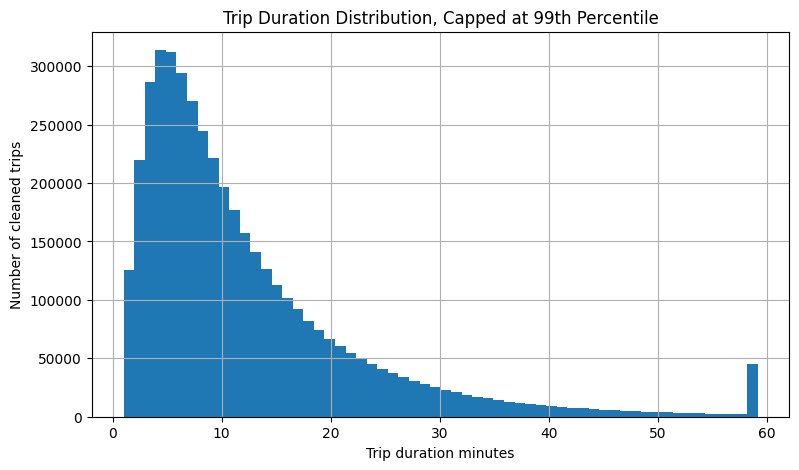

In [ ]:
plot_df = df_features.dropna(subset=['trip_duration_minutes']).copy()
duration_cap = plot_df['trip_duration_minutes'].quantile(0.99)
plot_df['duration_minutes_capped_99'] = plot_df['trip_duration_minutes'].clip(upper=duration_cap)

ax = plot_df['duration_minutes_capped_99'].hist(bins=60)
ax.set_title('Trip Duration Distribution, Capped at 99th Percentile')
ax.set_xlabel('Trip duration minutes')
ax.set_ylabel('Number of cleaned trips')
plt.show()

**Interpretation placeholder:** After running this plot, we should describe whether the duration distribution is strongly skewed and whether there are long-ride outliers. This matters because regression models can be affected by extreme target values. If the distribution is very skewed, we may compare raw duration with a log-transformed target or filter extreme outliers for the first model.

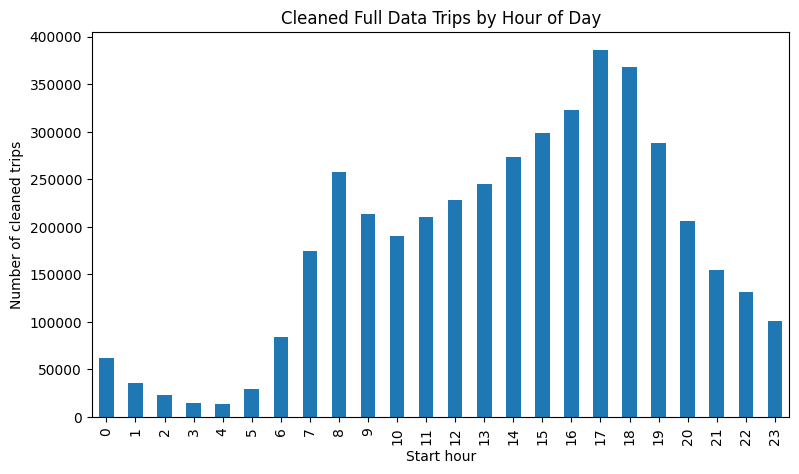

In [ ]:
hour_counts = df_features['start_hour'].value_counts().sort_index()
ax = hour_counts.plot(kind='bar')
ax.set_title('Cleaned Full Data Trips by Hour of Day')
ax.set_xlabel('Start hour')
ax.set_ylabel('Number of cleaned trips')
plt.show()

**Interpretation placeholder:** After running this plot, we should note whether the trip counts show commute-like peaks or a flatter recreational pattern. This matters because time of day is likely to be predictive of duration. It will also help justify using cyclical time encoding instead of treating hour as a plain linear number.

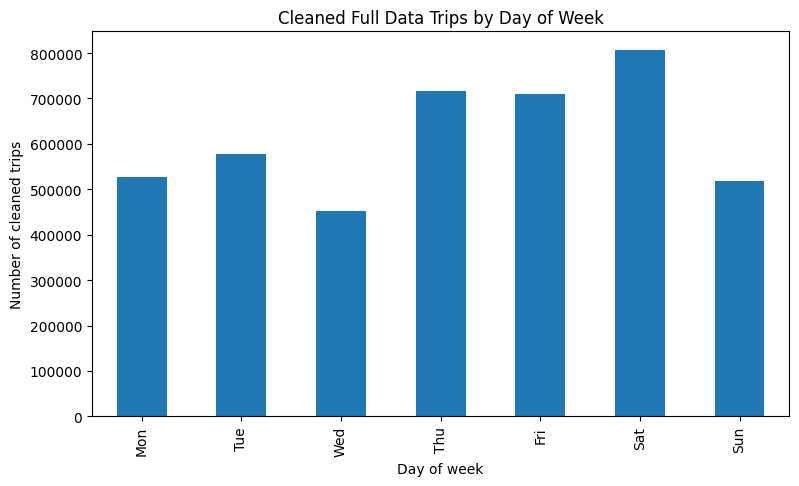

In [ ]:
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_counts = df_features['start_dayofweek'].value_counts().sort_index()
day_counts.index = [day_names[i] for i in day_counts.index]
ax = day_counts.plot(kind='bar')
ax.set_title('Cleaned Full Data Trips by Day of Week')
ax.set_xlabel('Day of week')
ax.set_ylabel('Number of cleaned trips')
plt.show()

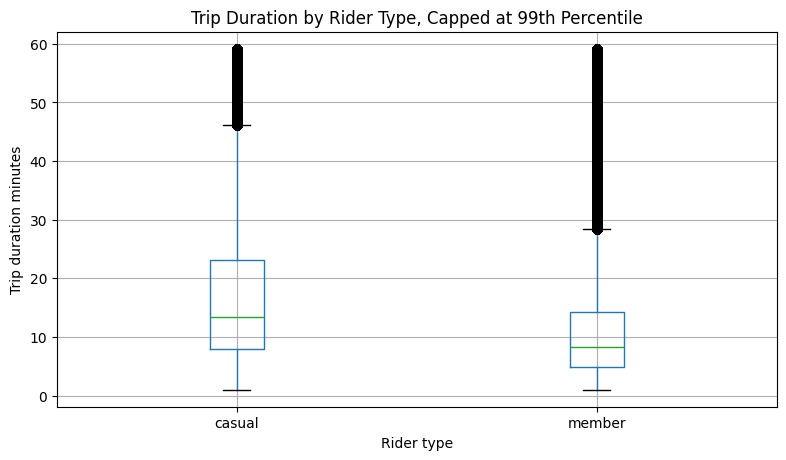

In [ ]:
ax = plot_df.boxplot(column='duration_minutes_capped_99', by='member_casual')
ax.set_title('Trip Duration by Rider Type, Capped at 99th Percentile')
ax.set_xlabel('Rider type')
ax.set_ylabel('Trip duration minutes')
plt.suptitle('')
plt.show()

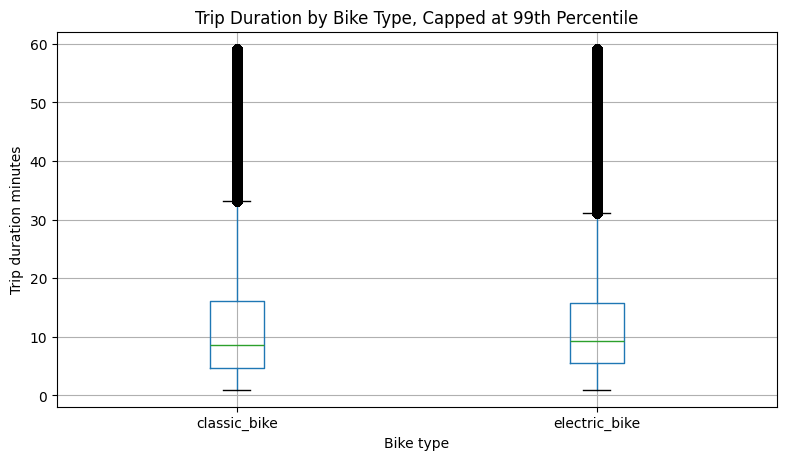

In [ ]:
ax = plot_df.boxplot(column='duration_minutes_capped_99', by='rideable_type')
ax.set_title('Trip Duration by Bike Type, Capped at 99th Percentile')
ax.set_xlabel('Bike type')
ax.set_ylabel('Trip duration minutes')
plt.suptitle('')
plt.show()

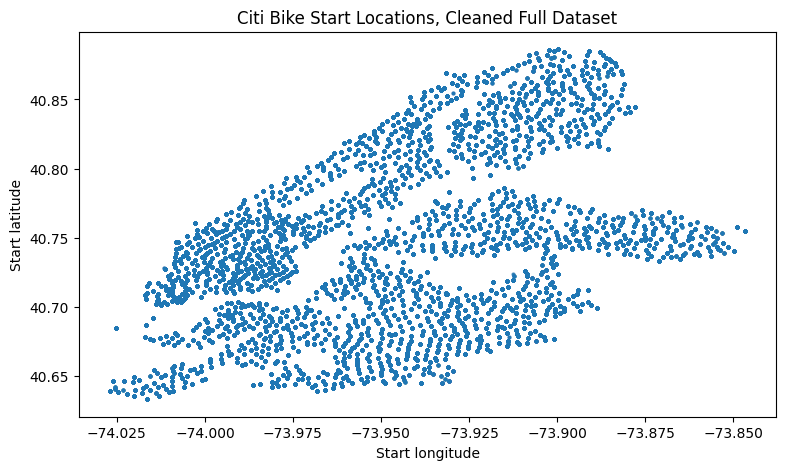

In [ ]:
location_df = df_features.dropna(subset=['start_lat', 'start_lng'])
ax = location_df.plot(
    kind='scatter',
    x='start_lng',
    y='start_lat',
    alpha=0.08,
    s=3,
)
ax.set_title('Citi Bike Start Locations, Cleaned Full Dataset')
ax.set_xlabel('Start longitude')
ax.set_ylabel('Start latitude')
plt.show()

## Literature Review and Prior Approaches

A lot of bike-sharing research focuses on demand prediction, station balancing, and spatiotemporal usage patterns. That is not exactly the same as our trip-duration regression task, but the feature ideas still transfer: time, location, station relationships, and user/rider context are important.

Useful sources so far:

- Citi Bike's official system data page explains the public trip history fields and notes that monthly files with more than one million trips may be split across multiple CSV files. This supports how we combined the five May 2025 files. Source: [Citi Bike System Data](https://citibikenyc.com/system-data).
- Jiang (2022) surveys deep learning for bike-sharing usage prediction and emphasizes temporal dependence, spatial interactions, and external factors. The survey also lists common baselines such as linear regression, random forest, gradient boosting, XGBoost, ARIMA, and neural network models. Source: [Bike sharing usage prediction with deep learning: a survey](https://pmc.ncbi.nlm.nih.gov/articles/PMC9185130/).
- Yang et al. (2018) used a CNN-based approach to predict daily Citi Bike pickups at city and station levels. We are not doing the same task, but it supports the idea that Citi Bike data has strong spatial and temporal structure. Source: [Use of Deep Learning to Predict Daily Usage of Bike Sharing Systems](https://journals.sagepub.com/doi/10.1177/0361198118801354).
- A recent paper on bike-sharing trip duration and distance prediction uses models such as Random Forest, CatBoost, Bagging, and GRU. We will treat this as inspiration for model families, not as a result we have replicated. Source: [Predicting Trip Duration and Distance in Bike-Sharing Systems Using Dynamic Time Warping](https://www.tandfonline.com/doi/full/10.1080/08839514.2025.2474786?af=R).

Common modeling approaches we can reasonably compare:

- Simple baseline: predict the training-set mean or median duration
- Linear regression: interpretable baseline using temporal features
- Random forest: handles nonlinear relationships and feature interactions
- Gradient boosting / XGBoost: likely stronger tree-based approach if time allows



## Proposed Methodological Approach

**Baseline model:** Predict trip duration using simple temporal features. This will give us a reference point that is easy to explain.

**Improved model:** Use a tree-based regressor with temporal features, rider type, bike type, start/end coordinates, and route distance.



## Initial Modeling Plan

We will use a train/validation/test split. Since this is time-based transportation data, we should discuss whether a random split is acceptable. For the first quick baseline, a random split is fine for debugging. For the more honest final evaluation, a time-based split may be better, such as training on earlier May trips and testing on later May trips.

Evaluation metrics:

- **MAE:** Mean absolute error in minutes. This is easy to explain: on average, how many minutes off are we?
- **RMSE:** Root mean squared error in minutes. This penalizes large mistakes more strongly than MAE.
- **R²:** Proportion of variance explained. This helps compare whether the model is doing better than a simple mean baseline.


## References


- Citi Bike. "System Data." https://citibikenyc.com/system-data
- Jiang, W. (2022). "Bike sharing usage prediction with deep learning: a survey." *Neural Computing and Applications*. https://pmc.ncbi.nlm.nih.gov/articles/PMC9185130/
- Yang, H., Xie, K., Ozbay, K., Ma, Y., & Wang, Z. (2018). "Use of Deep Learning to Predict Daily Usage of Bike Sharing Systems." *Transportation Research Record*. https://journals.sagepub.com/doi/10.1177/0361198118801354
- "Predicting Trip Duration and Distance in Bike-Sharing Systems Using Dynamic Time Warping." *Applied Artificial Intelligence* / Taylor & Francis. https://www.tandfonline.com/doi/full/10.1080/08839514.2025.2474786?af=R
